In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db, tune as tu, stats as su, img as iu
import numpy as np
from paths.config import M2PConfig
import matplotlib.pyplot as plt
import scipy
import plotly.express as px
from scipy.stats import ranksums, wilcoxon
import matplotlib as mpl
from classes.ProcPath import ProcPath
from classes import Experiment, S2PData
from matplotlib.colors import ListedColormap

In [3]:


LINEWIDTH_HIST = 3



PLOT_DPI = 300


# Don't know why this yucky grid is on
plt.style.use(['default'])
plt.rcParams['axes.grid'] = False
plt.rcParams.update({'font.size': 12})


cfg = M2PConfig()

In [4]:
# Same as in info notebook
print("Loading data")
df_exps, df_roi, df_ca, df_behave, df_behave_ca = db.get_ca_behave_data(cfg, 
                                                                        exclude_bad_behave=None,
                                                                        exclude_bad_2p=True, 
                                                                        roi_type=None,
                                                                        #max_speed=20,
                                                                        #max_ahv_abs=300,
                                                                        min_ear_dist=None,
                                                                        max_ear_dist=None,
                                                                        )

print("Loading connected pair data")
df_pair_conn = pd.read_hdf(cfg.db_conn_pair_file, key="key")
print("Loading pair ca data")
df_pair_ca = pd.read_hdf(cfg.db_somadend_ca_file, key="key")

print("Filtering ROI")
min_events = 30
df_roi = df_roi[df_roi["n_events"] >= min_events]

EXP_ROI_ID = "exp_id_roi_id"
df_roi[EXP_ROI_ID] = df_roi["exp_id"] + "_" + df_roi["roi_id"].astype(str)
df_behave_ca[EXP_ROI_ID] = df_behave_ca["exp_id"] + "_" + df_behave_ca["roi_id"].astype(str)

df_behave_ca = df_behave_ca[df_behave_ca[EXP_ROI_ID].isin(df_roi[EXP_ROI_ID])]
print("Done")
AHV_FILT_GRAD_ABS = bu.AHV_FILT_GRAD + "-abs"
df_behave_ca[AHV_FILT_GRAD_ABS] = np.abs(df_behave_ca[bu.AHV_FILT_GRAD])


print("Filtering unconnected dendrites")
EXP_SOMA_ID = "exp_id_soma_id"
EXP_DEND_ID = "exp_id_dend_id"
df_pair_conn[EXP_SOMA_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_1"].astype(str)
df_pair_conn[EXP_DEND_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_2"].astype(str)
# Get indexes of all soma and dendirtes that are connected to a dendrite.
soma_and_pairdend_indexes = np.logical_or(df_roi["roi_type"] == "soma",
                            np.logical_and(df_roi["roi_type"] == "dend",
                                           df_roi[EXP_ROI_ID].isin(df_pair_conn[EXP_DEND_ID])))

# # Filter down to just soma, and dendrites that are connected to soma
df_roi = df_roi[soma_and_pairdend_indexes]
df_behave_ca = df_behave_ca[df_behave_ca[EXP_ROI_ID].isin(df_roi[EXP_ROI_ID])]

df_behave_ca_orig = df_behave_ca.copy(deep=True)

print(df_roi["roi_type"].unique())

df_pair_ca_conn = df_pair_ca[df_pair_ca['pair_id'].isin(df_pair_conn['pair_id'].unique())].copy(deep=True)


Loading data
Excluded 26221 bad 2p frames 0.54%
Loading connected pair data
Loading pair ca data
Filtering ROI
Done
Filtering unconnected dendrites
['soma' 'dend']


In [ ]:


RESPONSE_TYPE = cu.CA_DFONF0

# for index, row in df_pair_conn.iterrows():
# 
#     exp_id = row["exp_id"]
#     soma_id = row["roi_index_1"]
#     dend_id = row["roi_index_2"] 
#     
#     if not (exp_id=="20211028_11_25_50_1115465" and soma_id==11 and dend_id==5):
#         continue

# exp_id = "20211028_11_25_50_1115465"
# soma_id = 13
# dend_id = 12

# exp_id = "20210823_16_59_50_1114353"
# soma_id = 2
# dend_id = 17

# exp_id = "20221003_14_36_54_1118020"
# soma_id = 0
# dend_id = 36

# exp_id = "20211203_15_10_27_1115464"
# soma_id = 6
# dend_id = 38


exp_id = "20211028_11_25_50_1115465"
soma_id = 11
dend_id = 97

print(exp_id, soma_id, dend_id)

# Get Ca trace for soma and dend
df_soma_ca = df_ca[(df_ca["exp_id"] == exp_id) & (df_ca["roi_id"] == soma_id)].copy(deep=True)
df_dend_ca = df_ca[(df_ca["exp_id"] == exp_id) & (df_ca["roi_id"] == dend_id)].copy(deep=True)

print(df_soma_ca.shape, df_dend_ca.shape)

# Get the pair ca data for this connected pair
df_this_pair_conn_ca = df_pair_ca_conn[(df_pair_ca_conn["exp_id"] == exp_id) & (df_pair_ca_conn["roi_index_1"] == soma_id) & (df_pair_ca_conn["roi_index_2"] == dend_id)].copy(deep=True)


print(df_this_pair_conn_ca.shape, df_this_pair_conn_ca.shape)

df_soma_ca_pair = df_soma_ca.merge(df_this_pair_conn_ca,
                        left_on=["exp_id", "roi_id", "frame_id"], 
                        right_on=["exp_id", "roi_index_1", "frame_id"],
                        how="inner")

df_dend_ca_pair = df_dend_ca.merge(df_this_pair_conn_ca,
                        left_on=["exp_id", "roi_id", "frame_id"], 
                        right_on=["exp_id", "roi_index_2", "frame_id"],
                        how="inner")

print(df_soma_ca_pair.shape, df_dend_ca_pair.shape)
    
    
    

In [ ]:


# local_event_onset_indexes = np.where(df_dend_ca_pair["event_dendritic"])[0]
# n_dend_events = local_event_onset_indexes.shape[0]
# print(n_dend_events)
# 
# 
# for i_dend_event in local_event_onset_indexes:
    # Plot the 2 traces

frame_offset = 100
#i_dend_event = 11689
# i_dend_event = 15508
i_dend_event = 3705


start_index = i_dend_event-frame_offset
if start_index < 0:
    start_index = 0
end_index = i_dend_event+frame_offset
if end_index > df_soma_ca_pair.shape[0]:
    end_index = df_soma_ca_pair.shape[0]
    
soma_ca_event = df_soma_ca_pair[start_index:end_index]
dend_ca_event = df_dend_ca_pair[start_index:end_index]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(soma_ca_event["time"], 
        soma_ca_event[RESPONSE_TYPE], 
        color=pu.COLOR_SOMA, 
        label="Soma")
ax.plot(dend_ca_event["time"], 
        dend_ca_event[RESPONSE_TYPE] + np.max(soma_ca_event[RESPONSE_TYPE]), 
        color=pu.COLOR_DEND, 
        label="Dendrite")

plt.vlines(soma_ca_event["time"].iloc[frame_offset], 
           ymin=np.min(soma_ca_event[RESPONSE_TYPE]), 
           ymax=np.max(dend_ca_event[RESPONSE_TYPE]), 
           color='black')

plt.legend(frameon=False)
plt.gca().axis('off')
# plt.title(i_dend_event)

#ax.set_xlim([220, 300])


plot_path = cfg.sum_trace_path / "trace-pair-{}-{}-{}-{}.png".format(exp_id, 
                                                                          soma_id, 
                                                                          dend_id, 
                                                                          i_dend_event)
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

plt.show()
ax.legend()
plt.show()

In [ ]:
np.max(df_dend_ca_pair[start_index:end_index][RESPONSE_TYPE])

In [ ]:
plt.plot(df_soma_ca_pair["event_dendritic"])

In [ ]:
plt.plot(df_dend_ca_pair["event_dendritic"])
plt.xlim([700, 750])

In [ ]:
np.where(df_dend_ca_pair["event_dendritic"])

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


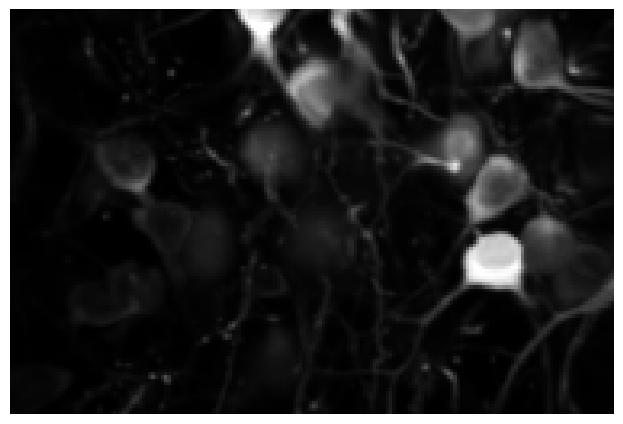

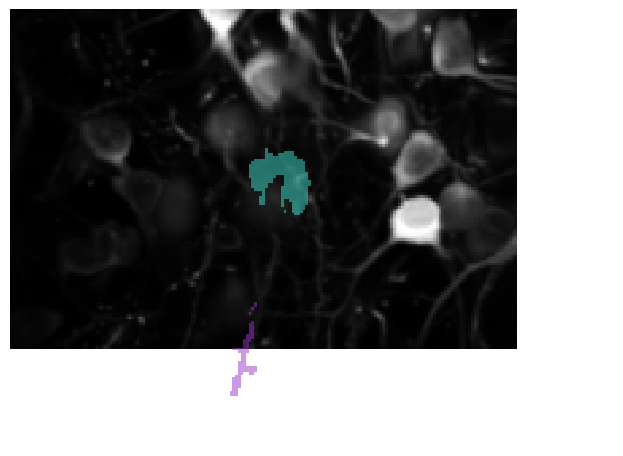

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


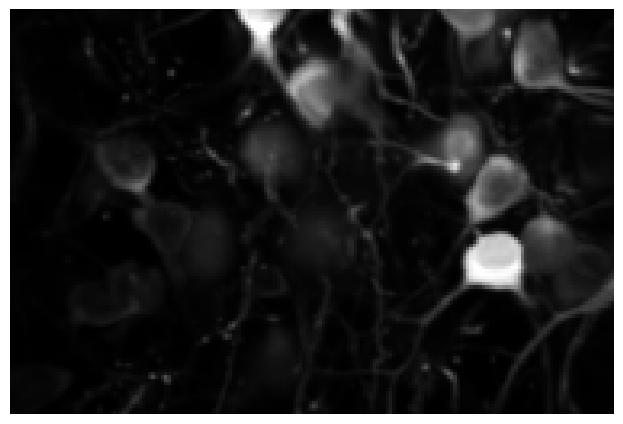

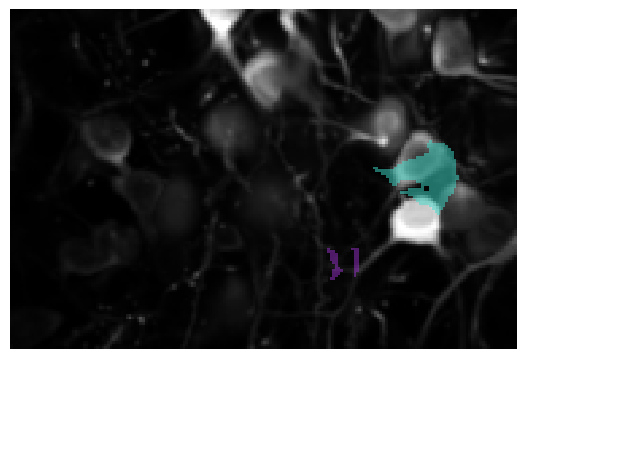

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


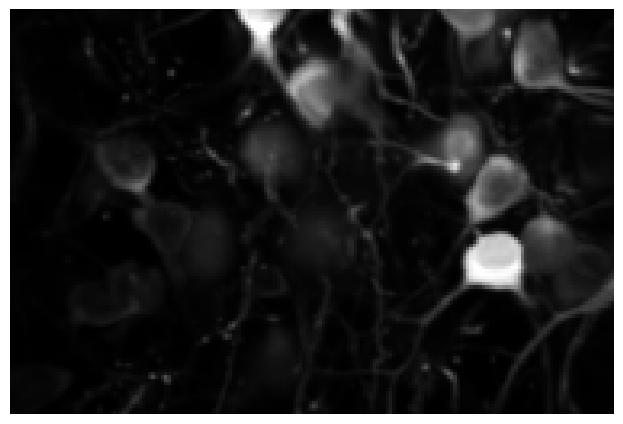

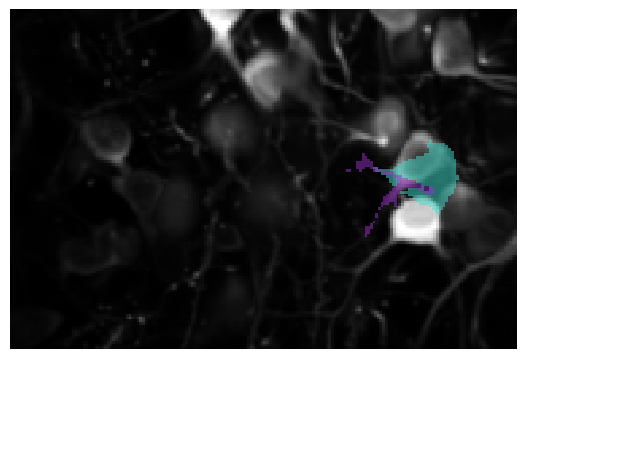

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


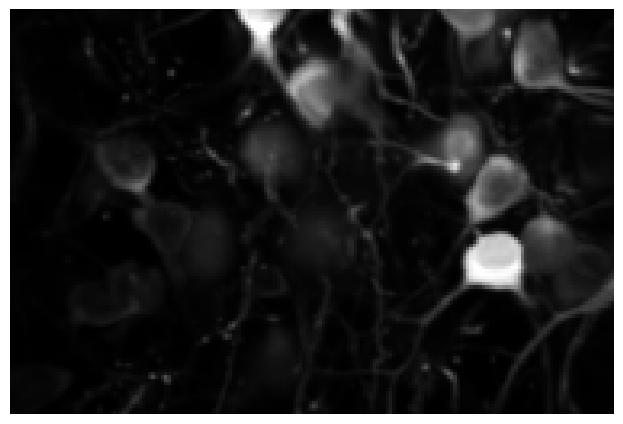

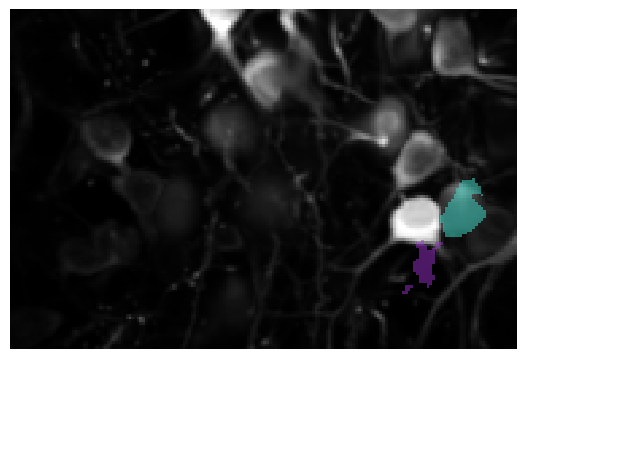

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


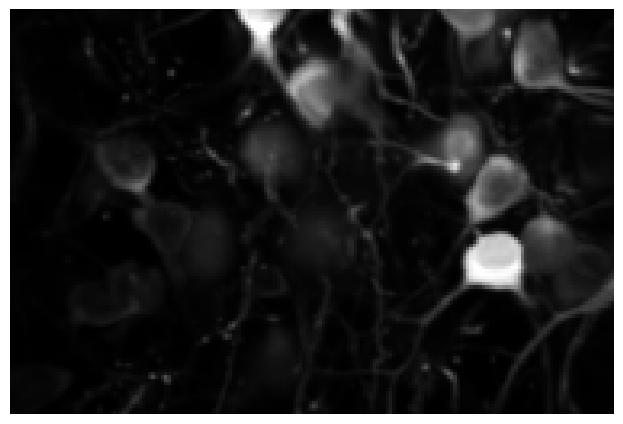

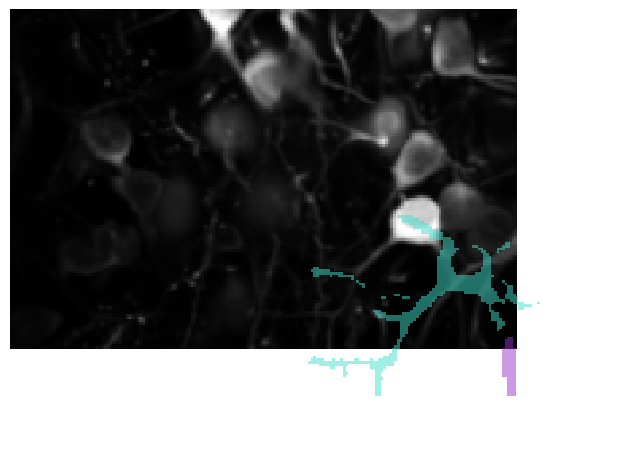

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


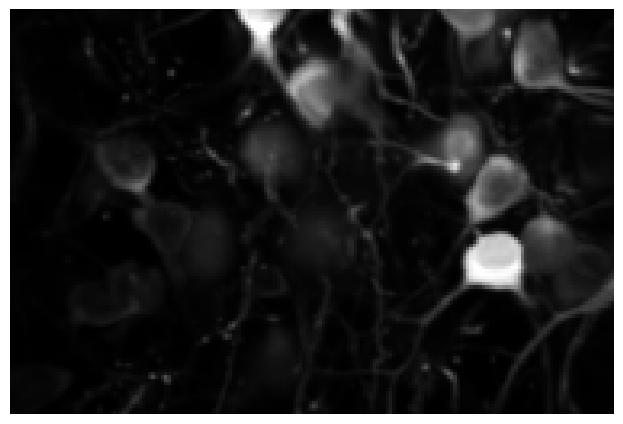

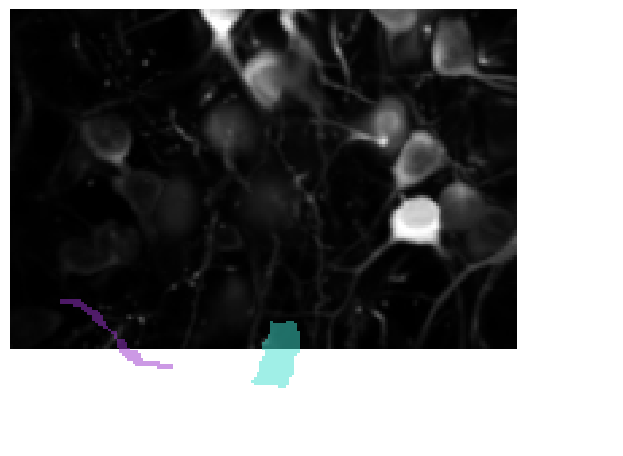

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


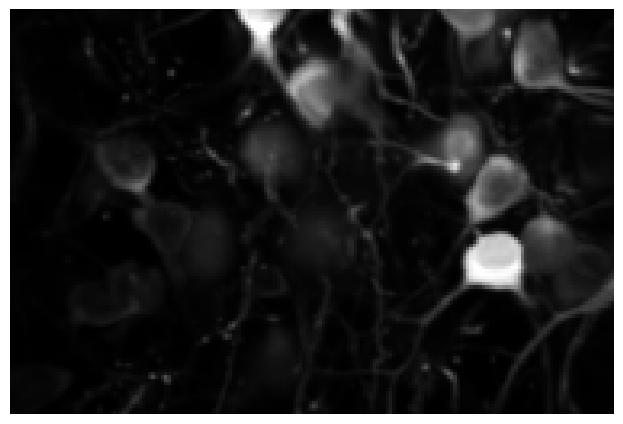

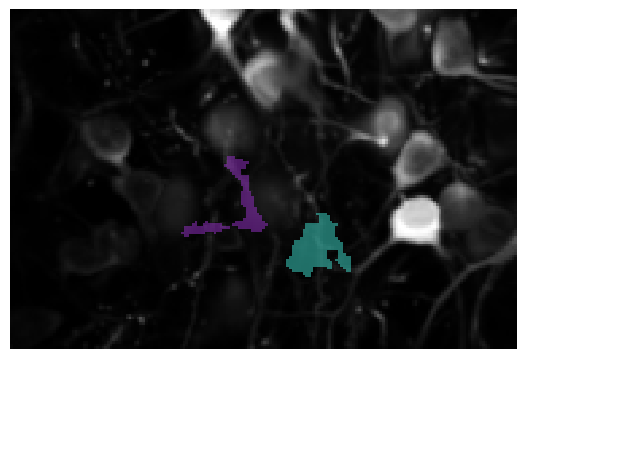

20210823_16_59_50_1114353
# roi cand=163, # roi good=16
Suite 2p data Loaded
# roi cand=163, # roi good=24
Suite 2p data Loaded


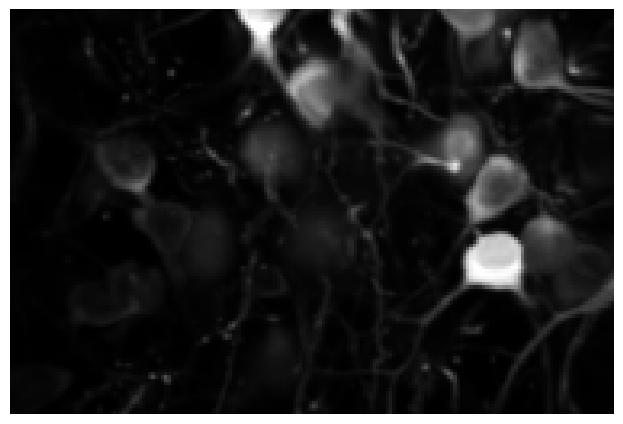

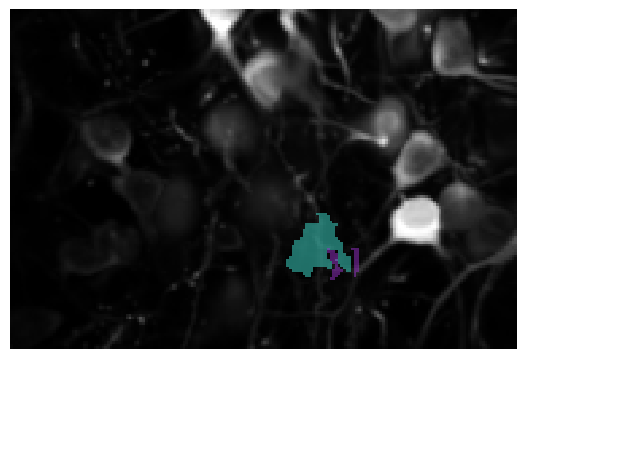

20211028_11_25_50_1115465
# roi cand=196, # roi good=22
Suite 2p data Loaded
# roi cand=196, # roi good=21
Suite 2p data Loaded


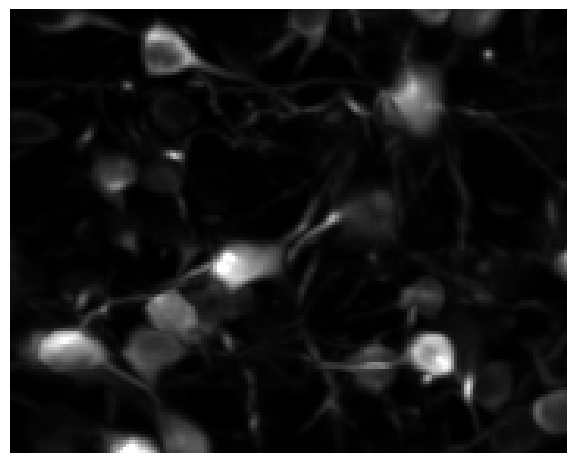

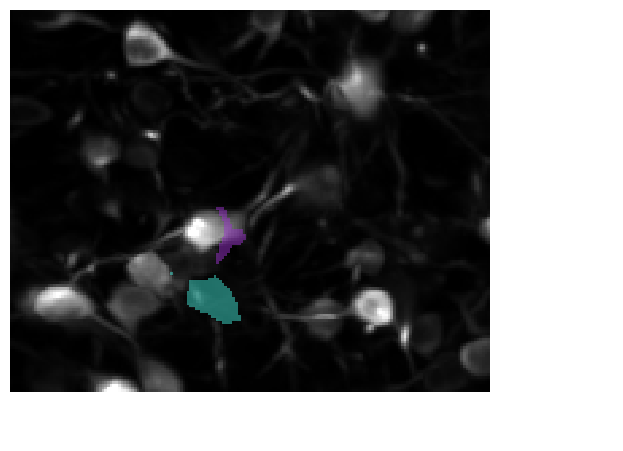

20211028_11_25_50_1115465
# roi cand=196, # roi good=22
Suite 2p data Loaded
# roi cand=196, # roi good=21
Suite 2p data Loaded


KeyboardInterrupt: 

In [30]:
for index, row in df_pair_conn.iterrows():

    exp_id = row["exp_id"]
    soma_id = row["roi_index_1"]
    dend_id = row["roi_index_2"] 
    
    print(exp_id)
    
    m2p_paths = ProcPath(cfg, exp_id)
    soma_data = S2PData.load_mode(m2p_paths.proc_s2p_path, "soma")
    dend_data = S2PData.load_mode(m2p_paths.proc_s2p_path, "dend")
    
    # Make image
    s2p_img = soma_data.ops["meanImg"]
    s2p_img_max = soma_data.ops["max_proj"]
    
    s2p_img = iu.normalize_img(s2p_img, 0.1)
    
    fig = plt.figure(tight_layout=False)
    plt.imshow(s2p_img, cmap=plt.cm.gray, interpolation="none")
    plt.gca().axis('off')
    
    fig = plt.figure(tight_layout=False)
    plt.imshow(s2p_img, cmap=plt.cm.gray, interpolation="none")
    plt.gca().axis('off')
    
    soma_img = np.zeros((soma_data.ops['Ly'], soma_data.ops['Lx']))
    soma_img[soma_data.stat[soma_id]["ypix"], soma_data.stat[soma_id]["xpix"]] = 1
    soma_img_mask = np.ma.masked_where(soma_img == 0, soma_img)
    
    dend_img = np.zeros((dend_data.ops['Ly'], dend_data.ops['Lx']))
    dend_img[dend_data.stat[dend_id]["ypix"], soma_data.stat[dend_id]["xpix"]] = 1
    dend_img_mask = np.ma.masked_where(dend_img == 0, dend_img)
     
    plt.imshow(soma_img_mask, cmap=ListedColormap([pu.COLOR_SOMA]), alpha=0.5)
    plt.imshow(dend_img_mask, cmap=ListedColormap([pu.COLOR_DEND]), alpha=0.5)
    
    # fig.savefig(plot_img_path, dpi=300, facecolor='white')
    plt.show()
    plt.cla()
    plt.clf()
    plt.close('all')
    #raise Exception("stop")
    

                         exp_id                           pair_id  \
58    20210823_16_59_50_1114353    20210823_16_59_50_1114353-2-43   
109   20210823_16_59_50_1114353   20210823_16_59_50_1114353-3-106   
110   20210823_16_59_50_1114353   20210823_16_59_50_1114353-3-111   
172   20210823_16_59_50_1114353    20210823_16_59_50_1114353-5-66   
231   20210823_16_59_50_1114353    20210823_16_59_50_1114353-7-52   
270   20210823_16_59_50_1114353    20210823_16_59_50_1114353-8-74   
316   20210823_16_59_50_1114353   20210823_16_59_50_1114353-10-29   
333   20210823_16_59_50_1114353  20210823_16_59_50_1114353-10-106   
920   20211028_11_25_50_1115465    20211028_11_25_50_1115465-4-39   
1117  20211028_11_25_50_1115465    20211028_11_25_50_1115465-11-5   
1125  20211028_11_25_50_1115465   20211028_11_25_50_1115465-11-52   
1131  20211028_11_25_50_1115465   20211028_11_25_50_1115465-11-97   
1148  20211028_11_25_50_1115465   20211028_11_25_50_1115465-13-12   
1703  20211203_15_10_27_1115464   

In [31]:
s2p_img = soma_data.ops["meanImg"]
s2p_img_max = soma_data.ops["max_proj"]
print(s2p_img.shape, s2p_img_max.shape)

(160, 224) (142, 178)


In [39]:
soma_data.ops.keys()

dict_keys(['suite2p_version', 'look_one_level_down', 'fast_disk', 'delete_bin', 'mesoscan', 'bruker', 'bruker_bidirectional', 'h5py', 'h5py_key', 'nwb_file', 'nwb_driver', 'nwb_series', 'save_path0', 'save_folder', 'subfolders', 'move_bin', 'nplanes', 'nchannels', 'functional_chan', 'tau', 'fs', 'force_sktiff', 'frames_include', 'multiplane_parallel', 'ignore_flyback', 'preclassify', 'save_mat', 'save_NWB', 'combined', 'aspect', 'do_bidiphase', 'bidiphase', 'bidi_corrected', 'do_registration', 'two_step_registration', 'keep_movie_raw', 'nimg_init', 'batch_size', 'maxregshift', 'align_by_chan', 'reg_tif', 'reg_tif_chan2', 'subpixel', 'smooth_sigma_time', 'smooth_sigma', 'th_badframes', 'norm_frames', 'force_refImg', 'pad_fft', 'nonrigid', 'block_size', 'snr_thresh', 'maxregshiftNR', '1Preg', 'spatial_hp_reg', 'pre_smooth', 'spatial_taper', 'roidetect', 'spikedetect', 'sparse_mode', 'spatial_scale', 'connected', 'nbinned', 'max_iterations', 'threshold_scaling', 'max_overlap', 'high_pass'

In [41]:
soma_data.ops['xrange']

[23, 201]

In [42]:
202-23

179